
# Scientific Conditional Diffusion for 2D Heat Fields

This notebook builds a **scientific conditional diffusion model** for 2D heat fields.
The task is not operator learning in the strict DeepONet/FNO sense. Instead, it is a
**scientific field reconstruction** problem:

- a smooth heat field is generated from a 2D heat equation,
- only a sparse set of sensor measurements is revealed,
- a conditional diffusion model reconstructs the full field,
- uncertainty is quantified from the spread of generated samples.

This is a useful scientific UQ example because it creates two clear uncertainty stories:

1. **spatial uncertainty** is larger away from observed sensors,
2. **OOD uncertainty** is larger for fields with sharper / higher-frequency structure than the training data.



## Physical problem

We use the 2D heat equation on a periodic unit square:

$$
\partial_t u = \kappa \Delta u, \qquad (x,y) \in [0,1)^2.
$$

Here:

- $u(x,y,t)$ is a temperature-like scalar field,
- $\kappa$ is the thermal diffusivity,
- diffusion damps high-frequency structure over time.

We first sample a random smooth initial field $u_0(x,y)$, then evolve it to a final time $T$.
The notebook reconstructs the final field from **sparse sensor observations** of that final field.

So the conditional generative task is:

$$
	ext{sparse observations of } u(x,y,T) \longrightarrow 	ext{distribution over full } u(x,y,T).
$$

That is why diffusion is a sensible model here: the conditioning does not completely determine the field, so multiple plausible reconstructions exist away from the sensors.


In [19]:
# Notebook bootstrap
# Force imports to resolve to the local repo source tree.

import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = str(PROJECT_ROOT / 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)


In [20]:
# Core imports and reproducibility

import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from deepuq.models import ConditionalUNet2D

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda



## Configuration

The default notebook path is a **quick, CPU-friendly configuration** that is small enough to run
in this environment. A slightly larger `full` mode is also provided for stronger results when a GPU
is available.

The important modeling knobs are:

- `sensor_stride`: how densely the field is observed,
- `hole_fraction`: size of the intentional sensor gap,
- `train_max_mode` / `ood_max_mode`: frequency content of the in-domain and OOD fields,
- `n_diffusion_steps`: number of DDPM denoising steps.


In [21]:
USE_QUICK_CONFIG = True

@dataclass
class ExperimentConfig:
    n_grid: int = 16
    n_train: int = 160
    n_val: int = 32
    n_test: int = 32
    n_ood: int = 32
    sensor_stride: int = 2
    hole_fraction: float = 0.34
    train_max_mode: int = 2
    ood_max_mode: int = 4
    train_amplitude: float = 1.0
    ood_amplitude: float = 1.4
    kappa: float = 0.08
    final_time: float = 0.12
    batch_size: int = 16
    epochs: int = 20
    lr: float = 2e-3
    weight_decay: float = 1e-4
    base_channels: int = 16
    time_dim: int = 64
    n_diffusion_steps: int = 10
    n_samples_test: int = 8
    compare_extra_samples: bool = False

if USE_QUICK_CONFIG:
    config = ExperimentConfig()
else:
    config = ExperimentConfig(
        n_grid=24,
        n_train=256,
        n_val=64,
        n_test=64,
        n_ood=64,
        batch_size=12,
        epochs=30,
        base_channels=24,
        time_dim=96,
        n_diffusion_steps=12,
    )

config


ExperimentConfig(n_grid=16, n_train=160, n_val=32, n_test=32, n_ood=32, sensor_stride=2, hole_fraction=0.34, train_max_mode=2, ood_max_mode=4, train_amplitude=1.0, ood_amplitude=1.4, kappa=0.08, final_time=0.12, batch_size=16, epochs=20, lr=0.002, weight_decay=0.0001, base_channels=16, time_dim=64, n_diffusion_steps=10, n_samples_test=8, compare_extra_samples=False)


## Input and output of the conditional diffusion model

For each sample:

- **conditioning input**:
  - sparse observed field values,
  - sensor mask,
  - a smooth inpainting baseline,
- **output**:
  - a full reconstructed heat field.

So the neural network does **not** directly map one deterministic field to another. Instead, it learns a denoising model for the conditional distribution


At inference time we generate several samples and compute:

- predictive mean field,
- predictive standard deviation field,
- in-domain vs OOD sample spread.


In [22]:
# Geometry, exact heat solver, and conditioning helpers
# - The final heat field is generated exactly in Fourier space.
# - The sensor mask deliberately leaves a central hole with no measurements.
# - A normalized blur baseline gives the diffusion model a physically reasonable starting guess.

x = torch.linspace(0.0, 1.0, config.n_grid)
y = torch.linspace(0.0, 1.0, config.n_grid)
YY, XX = torch.meshgrid(y, x, indexing='ij')


def sample_initial_fields(
    n_samples: int,
    *,
    max_mode: int,
    amplitude: float,
    seed: int,
) -> torch.Tensor:
    generator = torch.Generator().manual_seed(seed)
    field = torch.zeros(n_samples, config.n_grid, config.n_grid)
    for kx in range(1, max_mode + 1):
        for ky in range(1, max_mode + 1):
            coeff = amplitude * torch.randn(n_samples, generator=generator) / (kx * kx + ky * ky) ** 1.4
            phase = 2.0 * math.pi * torch.rand(n_samples, generator=generator)
            basis = torch.sin(2.0 * math.pi * (kx * XX + ky * YY) + phase[:, None, None])
            field = field + coeff[:, None, None] * basis
    return field.float()


def evolve_heat_exact(u0: torch.Tensor) -> torch.Tensor:
    kx = torch.fft.fftfreq(config.n_grid, d=1.0 / config.n_grid).to(u0)
    ky = torch.fft.fftfreq(config.n_grid, d=1.0 / config.n_grid).to(u0)
    KY, KX = torch.meshgrid(ky, kx, indexing='ij')
    decay = torch.exp(-4.0 * math.pi**2 * config.kappa * config.final_time * (KX**2 + KY**2))
    u0_ft = torch.fft.fftn(u0, dim=(-2, -1), norm='ortho')
    return torch.fft.ifftn(u0_ft * decay, dim=(-2, -1), norm='ortho').real.float()


def make_sensor_mask() -> torch.Tensor:
    mask = torch.zeros(config.n_grid, config.n_grid)
    mask[:: config.sensor_stride, :: config.sensor_stride] = 1.0
    hole = int(round(config.hole_fraction * config.n_grid))
    start = max((config.n_grid - hole) // 2, 1)
    end = min(start + hole, config.n_grid - 1)
    mask[start:end, start:end] = 0.0
    # Keep the outer boundary observed so the field is physically anchored.
    mask[0, :] = 1.0
    mask[-1, :] = 1.0
    mask[:, 0] = 1.0
    mask[:, -1] = 1.0
    return mask.float()


GAUSSIAN_KERNEL = torch.tensor(
    [[1.0, 2.0, 1.0], [2.0, 4.0, 2.0], [1.0, 2.0, 1.0]],
    dtype=torch.float32,
)
GAUSSIAN_KERNEL = (GAUSSIAN_KERNEL / GAUSSIAN_KERNEL.sum()).view(1, 1, 3, 3)
SENSOR_MASK = make_sensor_mask()


def normalized_blur_inpaint(observed: torch.Tensor, mask: torch.Tensor, passes: int = 18) -> torch.Tensor:
    observed = observed.unsqueeze(1)
    mask = mask.unsqueeze(1)
    numerator = observed.clone()
    denominator = mask.clone()
    kernel = GAUSSIAN_KERNEL.to(observed)
    for _ in range(passes):
        numerator = F.conv2d(numerator, kernel, padding=1)
        denominator = F.conv2d(denominator, kernel, padding=1)
        numerator = numerator * (1.0 - mask) + observed
        denominator = denominator * (1.0 - mask) + mask
    return (numerator / denominator.clamp_min(1e-4)).squeeze(1)


def make_split(n_samples: int, *, max_mode: int, amplitude: float, seed: int) -> dict[str, torch.Tensor]:
    initial = sample_initial_fields(n_samples, max_mode=max_mode, amplitude=amplitude, seed=seed)
    target = evolve_heat_exact(initial)
    mask = SENSOR_MASK.expand(n_samples, -1, -1)
    observed = target * mask
    baseline = normalized_blur_inpaint(observed, mask)
    residual = target - baseline
    observed_residual = observed - baseline * mask
    return {
        'initial': initial,
        'target': target,
        'mask': mask,
        'observed': observed,
        'baseline': baseline,
        'residual': residual,
        'observed_residual': observed_residual,
    }


class Standardizer:
    def __init__(self, reference: torch.Tensor, eps: float = 1e-5):
        self.mean = reference.mean(dim=0, keepdim=True)
        self.std = reference.std(dim=0, keepdim=True).clamp_min(eps)

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean.to(x.device, x.dtype)) / self.std.to(x.device, x.dtype)

    def inverse(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.std.to(x.device, x.dtype) + self.mean.to(x.device, x.dtype)



## Dataset logic and physical meaning

The training fields are deliberately smooth. That corresponds to heat fields generated from large-scale, slowly varying initial conditions.

The OOD fields are sharper and higher-frequency. Physically, these represent more structured thermal patterns than the model typically sees during training.

The sensor mask creates a **central region with no direct measurements**. That region should be harder to reconstruct, so the predictive standard deviation should grow there.


In [23]:
# Build the train / validation / test / OOD splits and normalize the residual target.

train_data = make_split(config.n_train, max_mode=config.train_max_mode, amplitude=config.train_amplitude, seed=11)
val_data = make_split(config.n_val, max_mode=config.train_max_mode, amplitude=config.train_amplitude, seed=17)
test_data = make_split(config.n_test, max_mode=config.train_max_mode, amplitude=config.train_amplitude, seed=23)
ood_data = make_split(config.n_ood, max_mode=config.ood_max_mode, amplitude=config.ood_amplitude, seed=29)

residual_standardizer = Standardizer(train_data['residual'])
baseline_standardizer = Standardizer(train_data['baseline'])

for split in (train_data, val_data, test_data, ood_data):
    split['residual_n'] = residual_standardizer.transform(split['residual'])
    split['observed_residual_n'] = residual_standardizer.transform(split['observed_residual'])
    split['baseline_n'] = baseline_standardizer.transform(split['baseline'])
    split['condition'] = torch.stack(
        [split['observed_residual_n'], split['mask'], split['baseline_n']],
        dim=1,
    )

print('Train target shape:', tuple(train_data['target'].shape))
print('Condition shape:', tuple(train_data['condition'].shape))
print('Observed fraction:', float(SENSOR_MASK.mean()))


Train target shape: (160, 16, 16)
Condition shape: (160, 3, 16, 16)
Observed fraction: 0.41015625


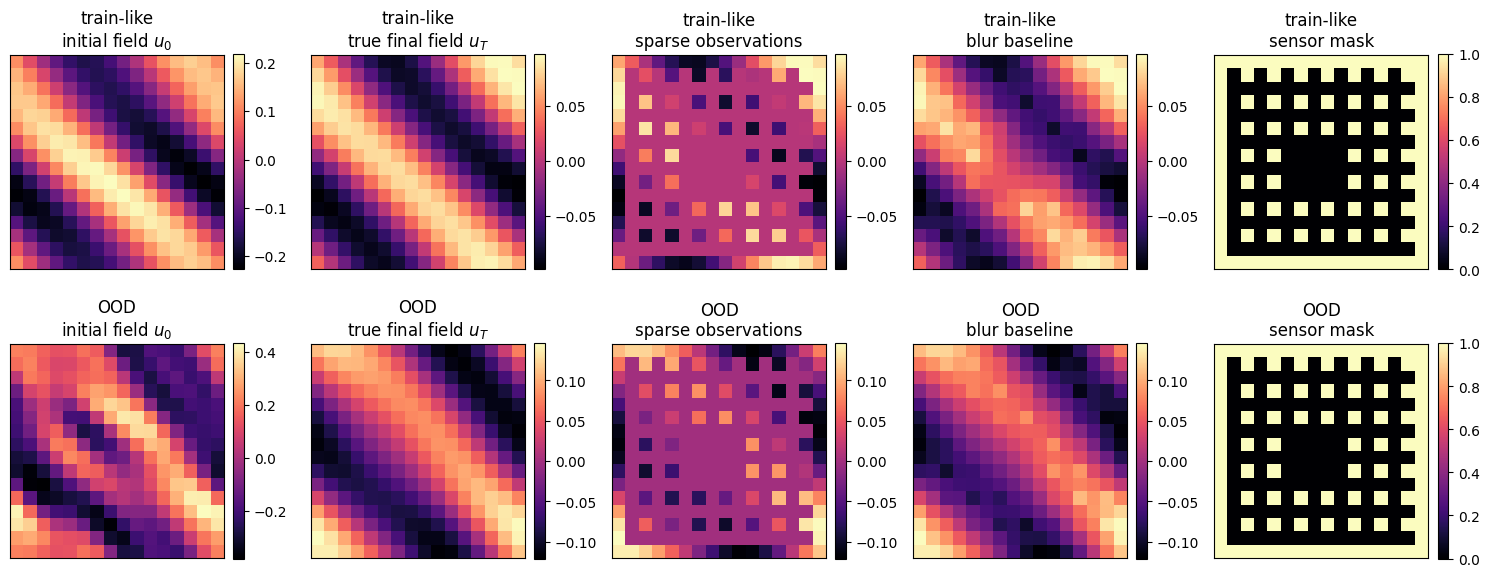

In [24]:
# Dataset diagnostics
# - first row: train example
# - second row: OOD example
# - the mask panel shows the deliberate sensor gap

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, (title, split) in enumerate([('train-like', train_data), ('OOD', ood_data)]):
    idx = 0
    items = [
        (split['initial'][idx], 'initial field $u_0$'),
        (split['target'][idx], 'true final field $u_T$'),
        (split['observed'][idx], 'sparse observations'),
        (split['baseline'][idx], 'blur baseline'),
        (split['mask'][idx], 'sensor mask'),
    ]
    for ax, (field, name) in zip(axes[row], items):
        im = ax.imshow(field.numpy(), origin='lower', cmap='magma')
        ax.set_title(f'{title}\n{name}')
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



## Conditional diffusion model

We train a DDPM-style denoiser on the **residual field**

$$
 r(x,y) = u(x,y,T) - u_{\mathrm{base}}(x,y).
$$

This is the logical training choice here:

- the baseline already handles the easy smooth interpolation part,
- the diffusion model only has to model the missing correction,
- sparse sensor values are enforced during sampling through a data-consistency clamp.

The network input at each denoising step is:

- the noisy residual sample $r_t$,
- the observed residual values,
- the sensor mask,
- the smooth baseline estimate.


In [25]:
# Diffusion schedule and dataloaders
# - Keep the diffusion schedule tensors on the same device as the model.
# - This avoids CPU/CUDA index mismatches when timesteps are sampled on GPU.

train_loader = DataLoader(
    TensorDataset(train_data['residual_n'].unsqueeze(1), train_data['condition']),
    batch_size=config.batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(val_data['residual_n'].unsqueeze(1), val_data['condition']),
    batch_size=config.batch_size,
)

betas = torch.linspace(1e-4, 1.2e-2, config.n_diffusion_steps, dtype=torch.float32, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


In [26]:
# Model, optimizer, and training helpers

model = ConditionalUNet2D(
    x_channels=1,
    cond_channels=3,
    base_channels=config.base_channels,
    time_dim=config.time_dim,
    dropout_p=0.0,
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)


def diffusion_training_step(model: nn.Module, x0: torch.Tensor, condition: torch.Tensor) -> torch.Tensor:
    t = torch.randint(0, config.n_diffusion_steps, (x0.size(0),), device=x0.device)
    noise = torch.randn_like(x0)
    alpha_bar = alpha_bars[t].to(x0.device).view(-1, 1, 1, 1)
    x_t = alpha_bar.sqrt() * x0 + (1.0 - alpha_bar).sqrt() * noise
    predicted_noise = model(x_t, t, condition)
    return F.mse_loss(predicted_noise, noise)


@torch.no_grad()
def estimate_validation_x0_error(model: nn.Module) -> float:
    model.eval()
    x0, condition = next(iter(val_loader))
    x0 = x0.to(device)
    condition = condition.to(device)
    t = torch.full((x0.size(0),), config.n_diffusion_steps - 1, dtype=torch.long, device=device)
    noise = torch.randn_like(x0)
    alpha_bar = alpha_bars[t].to(device).view(-1, 1, 1, 1)
    x_t = alpha_bar.sqrt() * x0 + (1.0 - alpha_bar).sqrt() * noise
    predicted_noise = model(x_t, t, condition)
    x0_hat = (x_t - (1.0 - alpha_bar).sqrt() * predicted_noise) / alpha_bar.sqrt()
    return float(F.mse_loss(x0_hat, x0).item())


In [27]:
# Training loop
# - The denoiser predicts diffusion noise on the normalized residual field.
# - We track both the raw denoising loss and a validation proxy for x0 reconstruction quality.

history = {'train_loss': [], 'val_x0_mse': []}
best_state = None
best_val = float('inf')

for epoch in range(config.epochs):
    model.train()
    total_loss = 0.0
    total_items = 0
    for x0, condition in train_loader:
        x0 = x0.to(device)
        condition = condition.to(device)
        loss = diffusion_training_step(model, x0, condition)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += float(loss.item()) * x0.size(0)
        total_items += x0.size(0)

    train_loss = total_loss / max(total_items, 1)
    val_x0_mse = estimate_validation_x0_error(model)
    history['train_loss'].append(train_loss)
    history['val_x0_mse'].append(val_x0_mse)

    if val_x0_mse < best_val:
        best_val = val_x0_mse
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(f'epoch={epoch:03d} train_loss={train_loss:.6f} val_x0_mse={val_x0_mse:.6f}')

model.load_state_dict(best_state)


epoch=000 train_loss=1.007842 val_x0_mse=0.061740
epoch=001 train_loss=0.994444 val_x0_mse=0.055401
epoch=002 train_loss=0.891106 val_x0_mse=0.038316
epoch=003 train_loss=0.702962 val_x0_mse=0.024930
epoch=004 train_loss=0.574695 val_x0_mse=0.017845
epoch=005 train_loss=0.516028 val_x0_mse=0.014918
epoch=006 train_loss=0.444570 val_x0_mse=0.012964
epoch=007 train_loss=0.413991 val_x0_mse=0.013134
epoch=008 train_loss=0.418435 val_x0_mse=0.011716
epoch=009 train_loss=0.386351 val_x0_mse=0.010159
epoch=010 train_loss=0.340168 val_x0_mse=0.010108
epoch=011 train_loss=0.336814 val_x0_mse=0.009485
epoch=012 train_loss=0.312514 val_x0_mse=0.008514
epoch=013 train_loss=0.296627 val_x0_mse=0.008040
epoch=014 train_loss=0.286589 val_x0_mse=0.007857
epoch=015 train_loss=0.265027 val_x0_mse=0.008102
epoch=016 train_loss=0.246950 val_x0_mse=0.007194
epoch=017 train_loss=0.248771 val_x0_mse=0.006527
epoch=018 train_loss=0.250184 val_x0_mse=0.006964
epoch=019 train_loss=0.259347 val_x0_mse=0.006273


<All keys matched successfully>

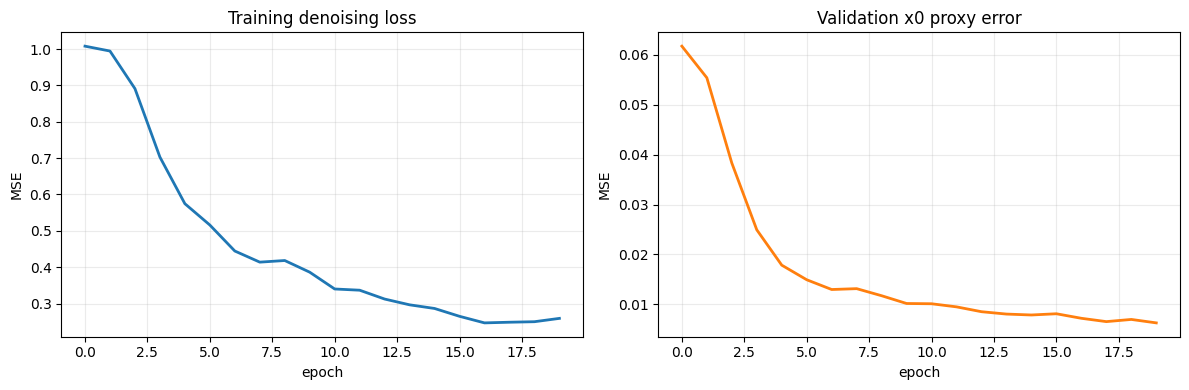

In [28]:
# Training curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], lw=2)
axes[0].set_title('Training denoising loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE')
axes[0].grid(alpha=0.25)

axes[1].plot(history['val_x0_mse'], lw=2, color='tab:orange')
axes[1].set_title('Validation x0 proxy error')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('MSE')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()



## Sampling and uncertainty estimation

We now draw multiple conditional samples and compute:

- sample mean field,
- sample standard deviation field,
- aggregate uncertainty statistics.

During reverse diffusion, we apply a **data-consistency clamp** at each step so the generated field stays equal to the observed values at sensor locations.
That is why uncertainty should be essentially zero at sensors and larger in unsensed regions.


In [29]:
@torch.no_grad()
def sample_residual_posterior(condition: torch.Tensor, observed_residual: torch.Tensor, mask: torch.Tensor, *, n_samples: int) -> torch.Tensor:
    condition = condition.to(device)
    observed_residual = observed_residual.to(device)
    mask = mask.to(device)
    n_eval = condition.size(0)
    samples = []
    for _ in range(n_samples):
        x = torch.randn(n_eval, 1, config.n_grid, config.n_grid, device=device)
        for step in reversed(range(config.n_diffusion_steps)):
            t = torch.full((n_eval,), step, dtype=torch.long, device=device)
            beta = betas[step].to(device)
            alpha = alphas[step].to(device)
            alpha_bar = alpha_bars[step].to(device)
            predicted_noise = model(x, t, condition)
            x0 = (x - (1.0 - alpha_bar).sqrt() * predicted_noise) / alpha_bar.sqrt()
            x0 = x0 * (1.0 - mask) + observed_residual * mask
            if step > 0:
                noise = torch.randn_like(x)
                x = (1.0 / alpha.sqrt()) * (x - (1.0 - alpha) / (1.0 - alpha_bar).sqrt() * predicted_noise) + beta.sqrt() * noise
                x = x * (1.0 - mask) + observed_residual * mask
            else:
                x = x0
        samples.append(x.cpu())
    return torch.stack(samples, dim=0)


@torch.no_grad()
def evaluate_split(split: dict[str, torch.Tensor]) -> dict[str, torch.Tensor | float]:
    residual_samples_n = sample_residual_posterior(
        split['condition'],
        split['observed_residual_n'].unsqueeze(1),
        split['mask'].unsqueeze(1),
        n_samples=config.n_samples_test,
    )
    residual_samples = residual_standardizer.inverse(residual_samples_n.squeeze(2))
    field_samples = residual_samples + split['baseline'].unsqueeze(0)
    mean = field_samples.mean(dim=0)
    std = field_samples.std(dim=0, unbiased=False)
    rmse = float(torch.mean((mean - split['target']) ** 2).sqrt().item())
    sensor_std = float((std * split['mask']).sum().item() / split['mask'].sum().item())
    unsensed_std = float((std * (1.0 - split['mask'])).sum().item() / (1.0 - split['mask']).sum().item())
    return {
        'samples': field_samples,
        'mean': mean,
        'std': std,
        'rmse': rmse,
        'mean_std': float(std.mean().item()),
        'sensor_std': sensor_std,
        'unsensed_std': unsensed_std,
    }


test_eval = evaluate_split(test_data)
ood_eval = evaluate_split(ood_data)

print(f"Baseline test RMSE: {torch.mean((test_data['baseline'] - test_data['target']) ** 2).sqrt().item():.6f}")
print(f"Diffusion test RMSE: {test_eval['rmse']:.6f}")
print(f"Baseline OOD RMSE:  {torch.mean((ood_data['baseline'] - ood_data['target']) ** 2).sqrt().item():.6f}")
print(f"Diffusion OOD RMSE:  {ood_eval['rmse']:.6f}")
print(f"Mean predictive std (test): {test_eval['mean_std']:.6f}")
print(f"Mean predictive std (OOD):  {ood_eval['mean_std']:.6f}")
print(f"Unsensed-region std (test): {test_eval['unsensed_std']:.6f}")
print(f"Sensor-region std (test):   {test_eval['sensor_std']:.6f}")

assert ood_eval['mean_std'] > test_eval['mean_std']
assert test_eval['unsensed_std'] > test_eval['sensor_std']


Baseline test RMSE: 0.025927
Diffusion test RMSE: 0.024632
Baseline OOD RMSE:  0.040984
Diffusion OOD RMSE:  0.038272
Mean predictive std (test): 0.009876
Mean predictive std (OOD):  0.010336
Unsensed-region std (test): 0.016744
Sensor-region std (test):   0.000000


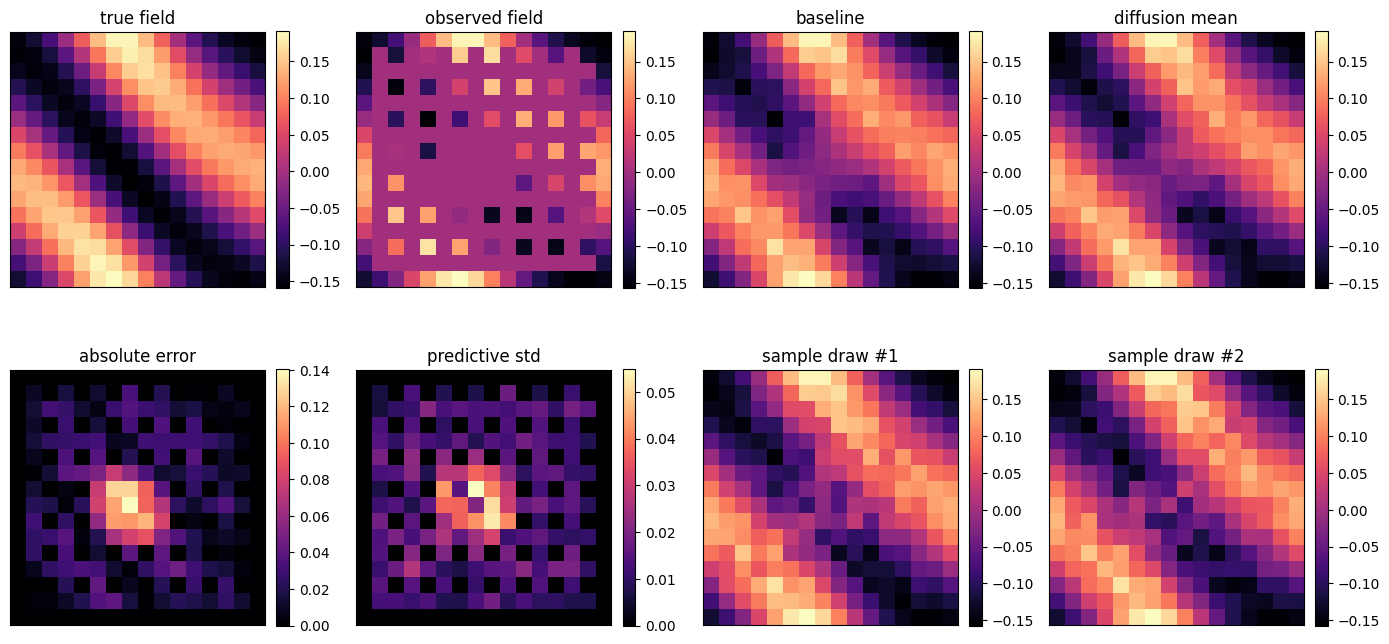

In [30]:
# Sample-level reconstruction diagnostics

sample_index = 0
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
items = [
    (test_data['target'][sample_index], 'true field'),
    (test_data['observed'][sample_index], 'observed field'),
    (test_data['baseline'][sample_index], 'baseline'),
    (test_eval['mean'][sample_index], 'diffusion mean'),
    ((test_eval['mean'][sample_index] - test_data['target'][sample_index]).abs(), 'absolute error'),
    (test_eval['std'][sample_index], 'predictive std'),
    (test_eval['samples'][0, sample_index], 'sample draw #1'),
    (test_eval['samples'][1, sample_index], 'sample draw #2'),
]
for ax, (field, title) in zip(axes.flat, items):
    im = ax.imshow(field.numpy(), origin='lower', cmap='magma')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


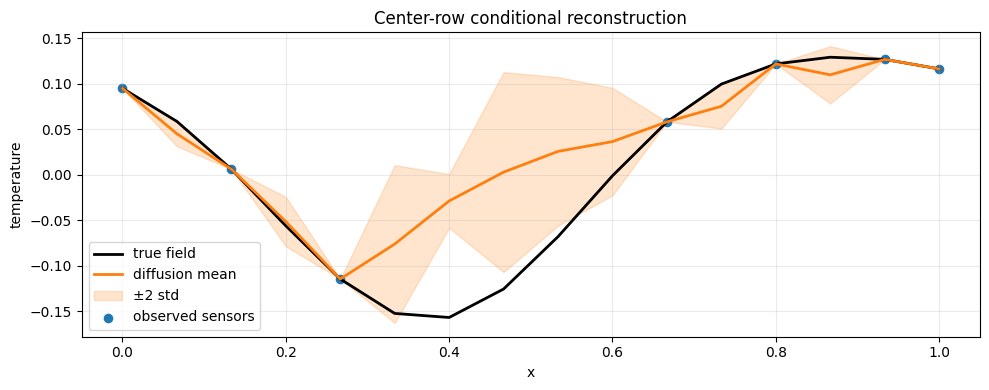

In [31]:
# Slice view through the center row
# - This makes the mean/std interpretation easier than only looking at heat maps.

row = config.n_grid // 2
x_coord = torch.linspace(0.0, 1.0, config.n_grid)
mean_row = test_eval['mean'][sample_index, row]
std_row = test_eval['std'][sample_index, row]
true_row = test_data['target'][sample_index, row]
obs_row = test_data['observed'][sample_index, row]
mask_row = test_data['mask'][sample_index, row]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_coord.numpy(), true_row.numpy(), color='black', lw=2, label='true field')
ax.plot(x_coord.numpy(), mean_row.numpy(), color='tab:orange', lw=2, label='diffusion mean')
ax.fill_between(
    x_coord.numpy(),
    (mean_row - 2.0 * std_row).numpy(),
    (mean_row + 2.0 * std_row).numpy(),
    color='tab:orange',
    alpha=0.2,
    label='±2 std',
)
ax.scatter(
    x_coord[mask_row > 0.5].numpy(),
    obs_row[mask_row > 0.5].numpy(),
    color='tab:blue',
    s=35,
    label='observed sensors',
)
ax.set_title('Center-row conditional reconstruction')
ax.set_xlabel('x')
ax.set_ylabel('temperature')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


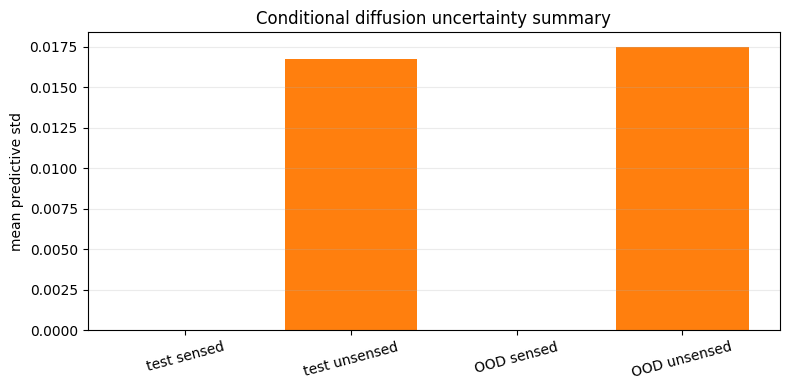

In [32]:
# Aggregate uncertainty comparison: sensed vs unsensed, in-domain vs OOD

labels = ['test sensed', 'test unsensed', 'OOD sensed', 'OOD unsensed']
values = [
    test_eval['sensor_std'],
    test_eval['unsensed_std'],
    ood_eval['sensor_std'],
    ood_eval['unsensed_std'],
]
colors = ['tab:blue', 'tab:orange', 'tab:blue', 'tab:orange']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, values, color=colors)
ax.set_ylabel('mean predictive std')
ax.set_title('Conditional diffusion uncertainty summary')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


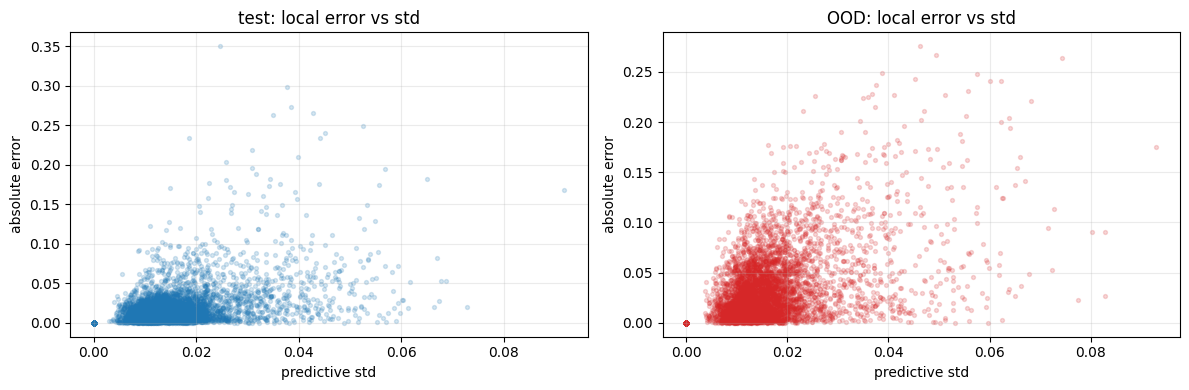

In [33]:
# Local error vs predictive std
# - A useful UQ sanity check: larger error should often coincide with larger predictive spread.

def scatter_error_vs_std(split: dict[str, torch.Tensor], evaluation: dict[str, torch.Tensor | float], title: str, color: str):
    absolute_error = (evaluation['mean'] - split['target']).abs().reshape(-1)
    predictive_std = evaluation['std'].reshape(-1)
    plt.scatter(predictive_std.numpy(), absolute_error.numpy(), s=8, alpha=0.18, color=color)
    plt.xlabel('predictive std')
    plt.ylabel('absolute error')
    plt.title(title)
    plt.grid(alpha=0.25)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
scatter_error_vs_std(test_data, test_eval, 'test: local error vs std', 'tab:blue')
plt.subplot(1, 2, 2)
scatter_error_vs_std(ood_data, ood_eval, 'OOD: local error vs std', 'tab:red')
plt.tight_layout()
plt.show()



## Interpretation

This notebook demonstrates a different uncertainty story than Laplace or MC Dropout.

Here, uncertainty is represented by the **spread of generated conditional samples**. That spread is meaningful because the conditioning is incomplete:

- at sensor locations, the field is observed and the reverse process is clamped there,
- away from sensors, the model must infer plausible completions,
- on OOD fields, the model encounters sharper structures than it saw during training.

So this notebook should show two patterns:

1. **test unsensed std > test sensed std**,
2. **OOD mean std > test mean std**.



## References

Primary references behind the notebook design:

- Ho, Jain, Abbeel (2020), *Denoising Diffusion Probabilistic Models*.
- Song et al. (2021), *Score-Based Generative Modeling through Stochastic Differential Equations*.
- Ronneberger, Fischer, Brox (2015), *U-Net: Convolutional Networks for Biomedical Image Segmentation*.

Scientific context:

- the 2D heat equation as a canonical diffusion PDE,
- sparse scientific sensing / field reconstruction,
- sample-based uncertainty through conditional generative models.
